<a href="https://colab.research.google.com/github/Arif0000/GFG-21-Days-Live-class-task/blob/main/Task5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
# Load the dataset from the user-provided file
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"
df = pd.read_csv('/content/Datasets/Mall Dataset/Mall_Customers.csv')

print("Dataset loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()


Cloning into 'Datasets'...
remote: Enumerating objects: 347, done.
remote: Counting objects: 100% (105/105), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 347 (delta 25), reused 0 (delta 0), pack-reused 242 (from 1)
Receiving objects: 100% (347/347), 302.89 MiB | 19.76 MiB/s, done.
Resolving deltas: 100% (139/139), done.
Updating files: 100% (245/245), done.
Dataset loaded successfully.
Data shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
df.info()

df.describe()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [5]:
gender_spending = df.groupby("Gender")["Spending Score (1-100)"].mean()
print(gender_spending)



Gender
Female    51.526786
Male      48.511364
Name: Spending Score (1-100), dtype: float64


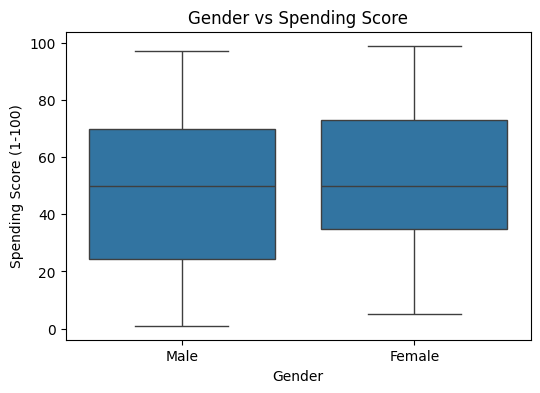

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Gender", y="Spending Score (1-100)", data=df)

plt.title("Gender vs Spending Score")
plt.show()



In [7]:
df["Spending_Efficiency"] = df["Spending Score (1-100)"] / df["Annual Income (k$)"]

df.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Spending_Efficiency
0,1,Male,19,15,39,2.600000
1,2,Male,21,15,81,5.400000
2,3,Female,20,16,6,0.375000
3,4,Female,23,16,77,4.812500
4,5,Female,31,17,40,2.352941


In [8]:
X = df[["Annual Income (k$)", "Spending_Efficiency"]]



In [9]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)



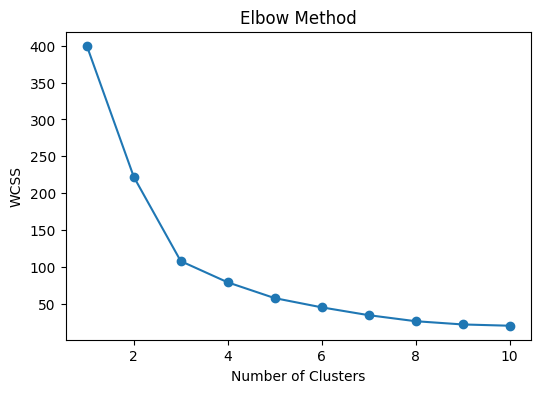

In [10]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(6,4))
plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()



In [11]:
kmeans = KMeans(n_clusters=4, random_state=42)

df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Spending_Efficiency,Cluster
0,1,Male,19,15,39,2.600000,2
1,2,Male,21,15,81,5.400000,2
2,3,Female,20,16,6,0.375000,3
3,4,Female,23,16,77,4.812500,2
4,5,Female,31,17,40,2.352941,3


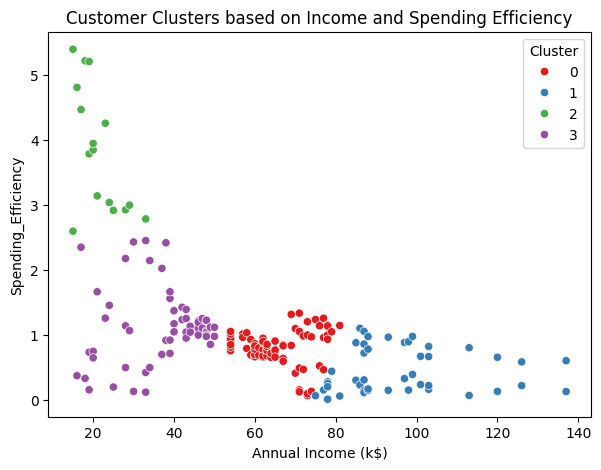

In [12]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Annual Income (k$)"],
    y=df["Spending_Efficiency"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Customer Clusters based on Income and Spending Efficiency")

plt.show()



In [13]:
df.groupby("Cluster")[["Annual Income (k$)", "Spending_Efficiency"]].mean()



,Annual Income (k$),Spending_Efficiency
Cluster,,
0,65.725000,0.829642
1,95.130435,0.441441
2,21.375000,3.836697
3,36.827586,1.131793
